In [1]:
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float, Array, PRNGKeyArray
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

In [2]:
class TruncatedFourier1D(eqx.Module):
    an: Float[Array, " K"]
    bn: Float[Array, " K"]
    a0: Float[Array, ""] = eqx.field(default_factory=lambda: jnp.array(0.0))
    L: float = eqx.field(static=True, default=1.0)

    def __call__(self, x: Float[Array, " *shape"]):
        kx: Float[Array, "*shape K"] = jnp.expand_dims(x, axis=-1) * self.wavenumbers
        cos_kx, sin_kx = jnp.cos(kx), jnp.sin(kx)
        return self.a0 + jnp.mean(
            self.an * cos_kx + self.bn * sin_kx, axis=-1
        ) / jnp.sqrt(2)

    @property
    def num_modes(self) -> int:
        return len(self.an)

    @property
    def wavenumbers(self) -> Float[Array, " K"]:
        return jnp.arange(1, self.num_modes + 1) * 2 * jnp.pi / self.L

    @classmethod
    def with_uniform_rand_coeffs(
        cls,
        num_modes: int,
        L: float = 1.0,
        coeff_range: tuple[float, float] = (1, 1),
        offset_range: tuple[float, float] | None = None,
        *,
        key: PRNGKeyArray = jax.random.PRNGKey(0),
    ):
        key_coeff, key_offset = jax.random.split(key, 2)
        an_bn = jax.random.uniform(
            key_coeff,
            shape=(2, num_modes),
            minval=coeff_range[0],
            maxval=coeff_range[1],
        )
        if offset_range is None:
            a0 = jnp.array(0.0)
        else:
            a0 = jax.random.uniform(
                key_offset, minval=offset_range[0], maxval=offset_range[1]
            )
        return cls(*an_bn, a0, L)

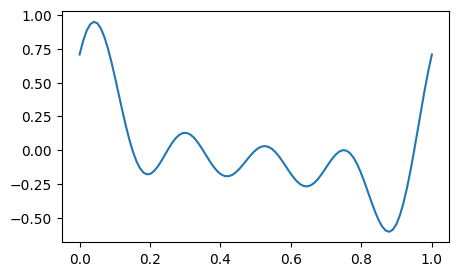

In [3]:
u0 = TruncatedFourier1D.with_uniform_rand_coeffs(num_modes=4)
x = jnp.linspace(0, 1, 100)
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x, u0(x))

In [4]:
from clawpack import pyclaw, riemann

riemann_solver = riemann.burgers_1D
solver = pyclaw.ClawSolver1D(riemann_solver)
solver.limiters = pyclaw.limiters.tvd.vanleer
solver.bc_lower[0] = pyclaw.BC.periodic
solver.bc_upper[0] = pyclaw.BC.periodic


In [5]:
from typing import Any
from collections.abc import Callable


class PDEProblem1D:
    pde: Any
    domain: Any
    bc: Any
    ic_factory: Callable

    def __init__(self, pde, x_min, x_max, Nx, bc):
        self.pde = pde


In [6]:
x = pyclaw.Dimension(0.0, 1.0, 1024, name="x")
domain = pyclaw.Domain(x)
state = pyclaw.State(domain, solver.num_eqn)

xc = state.grid.x.centers
state.q[0, :] = u0(xc)
state.problem_data["efix"] = True

solution = pyclaw.Solution(state, domain)

controller = pyclaw.Controller()
controller.outdir = "./temp/"
controller.solver = solver
controller.solution = solution
controller.tfinal = 0.6
controller.num_output_times = 1000
controller.keep_copy = True
controller.output_style = 1
controller.output_format = "ascii"

In [7]:
status = controller.run()

2025-07-07 21:03:15,400 INFO CLAW: Solution 0 computed for time t=0.000000
2025-07-07 21:03:15,407 INFO CLAW: Solution 1 computed for time t=0.000600
2025-07-07 21:03:15,414 INFO CLAW: Solution 2 computed for time t=0.001200
2025-07-07 21:03:15,420 INFO CLAW: Solution 3 computed for time t=0.001800
2025-07-07 21:03:15,426 INFO CLAW: Solution 4 computed for time t=0.002400


2025-07-07 21:03:15,433 INFO CLAW: Solution 5 computed for time t=0.003000
2025-07-07 21:03:15,439 INFO CLAW: Solution 6 computed for time t=0.003600
2025-07-07 21:03:15,445 INFO CLAW: Solution 7 computed for time t=0.004200
2025-07-07 21:03:15,451 INFO CLAW: Solution 8 computed for time t=0.004800
2025-07-07 21:03:15,457 INFO CLAW: Solution 9 computed for time t=0.005400
2025-07-07 21:03:15,464 INFO CLAW: Solution 10 computed for time t=0.006000
2025-07-07 21:03:15,470 INFO CLAW: Solution 11 computed for time t=0.006600
2025-07-07 21:03:15,476 INFO CLAW: Solution 12 computed for time t=0.007200
2025-07-07 21:03:15,483 INFO CLAW: Solution 13 computed for time t=0.007800
2025-07-07 21:03:15,489 INFO CLAW: Solution 14 computed for time t=0.008400
2025-07-07 21:03:15,496 INFO CLAW: Solution 15 computed for time t=0.009000
2025-07-07 21:03:15,502 INFO CLAW: Solution 16 computed for time t=0.009600
2025-07-07 21:03:15,508 INFO CLAW: Solution 17 computed for time t=0.010200
2025-07-07 21:03:

In [8]:
solution.__dict__

{'claw_package': <module 'clawpack.pyclaw' from '/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/clawpack/pyclaw/__init__.py'>,
 'states': [<clawpack.pyclaw.state.State at 0x1479c81e3ad0>],
 'domain': <clawpack.pyclaw.geometry.Domain at 0x1479c81c8200>,
 '_start_frame': 1001}

In [9]:
import numpy as np

sol = np.stack([f.state.q for f in controller.frames], axis=0)
sol.shape

(1001, 1, 1024)

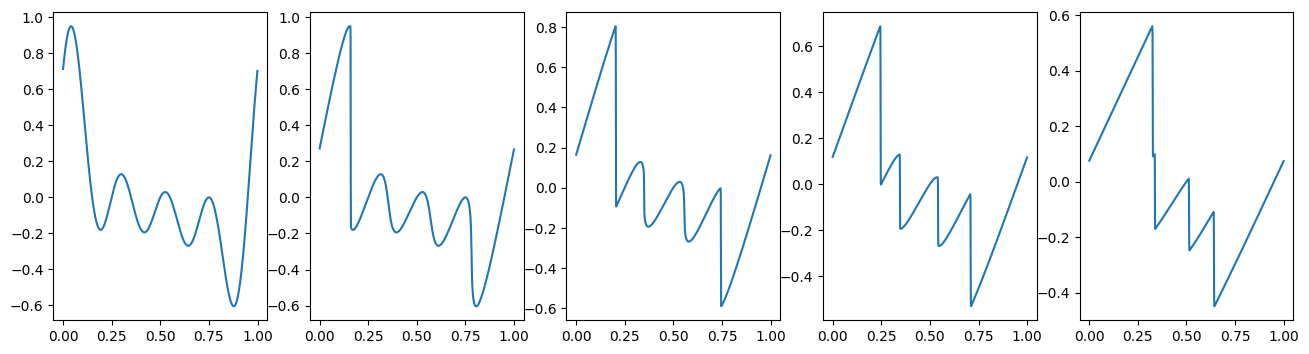

In [10]:
t_vals = (0, 200, 400, 600, 1000)
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharex=True)
for j, t_i in enumerate(t_vals):
    axes[j].plot(xc, sol[t_i, 0])

In [11]:
sol[0].shape

(1, 1024)

In [ ]:
from context_flux_no.models.fno import FNO1D

fno = FNO1D(
    data_dim=1, lift_dim=64, depth=4, frequency_modes=8, key=jax.random.PRNGKey(0)
)


In [49]:
out = fno(sol[0])

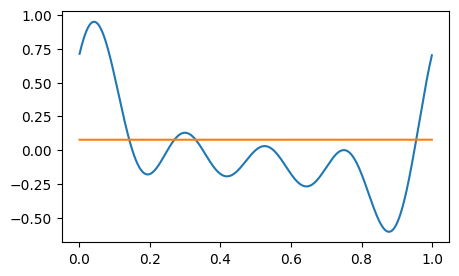

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(xc, sol[0][0])
ax.plot(xc, out[0])

In [51]:
sol[1:501].shape

(500, 1, 1024)

In [52]:
import optax


@eqx.filter_value_and_grad
def loss_fn(model, u0, u1):
    u1_pred = eqx.filter_vmap(model)(u0)
    return jnp.mean((u1_pred - u1) ** 2)


optim = optax.adabelief(learning_rate=1e-3)
opt_state = optim.init(eqx.filter(fno, eqx.is_array))


@eqx.filter_jit
def make_step(model, u0, u1, opt_state):
    loss, grads = loss_fn(model, u0, u1)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


In [53]:
max_epochs = 100
loss_history = []
for i in range(max_epochs):
    fno, opt_state, loss = make_step(fno, sol[0:300], sol[1:301], opt_state)
    loss_history.append(loss)
    print(f"Epoch = {i}: Loss = {loss.item()}")

Epoch = 0: Loss = 0.12633337850817666
Epoch = 1: Loss = 0.12357777251503374
Epoch = 2: Loss = 0.12152379212223277
Epoch = 3: Loss = 0.12018944910781439
Epoch = 4: Loss = 0.11948399593675509
Epoch = 5: Loss = 0.11912471827349083
Epoch = 6: Loss = 0.11866409337967208
Epoch = 7: Loss = 0.11766658477243691
Epoch = 8: Loss = 0.11580977055814279
Epoch = 9: Loss = 0.11283594167521893
Epoch = 10: Loss = 0.1084833286555561
Epoch = 11: Loss = 0.10245602932822746
Epoch = 12: Loss = 0.09446905741239231
Epoch = 13: Loss = 0.08443650966262088
Epoch = 14: Loss = 0.0729014183302687
Epoch = 15: Loss = 0.061344482331763456
Epoch = 16: Loss = 0.04949945946891236
Epoch = 17: Loss = 0.0352215036086436
Epoch = 18: Loss = 0.021183407400018915
Epoch = 19: Loss = 0.0119707284560994
Epoch = 20: Loss = 0.01080665770531576
Epoch = 21: Loss = 0.01893604314466769
Epoch = 22: Loss = 0.02354933688702199
Epoch = 23: Loss = 0.019428109237552945
Epoch = 24: Loss = 0.012217550972223112
Epoch = 25: Loss = 0.00664789514555

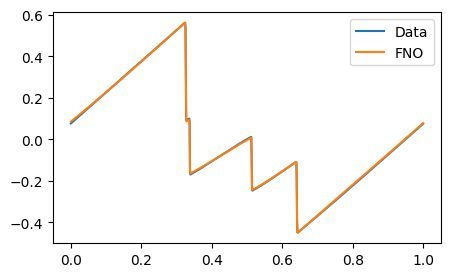

In [55]:
time_idx = 1000
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(xc, sol[time_idx][0], label="Data")
ax.plot(xc, fno(sol[time_idx])[0], label="FNO")
ax.legend()